In [20]:
import json
import pathlib
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
folder = "../metrics_h4"
p = pathlib.Path(folder)

In [15]:
filepaths = list(p.glob("*.json"))

In [16]:
metrics_data = []
for f in filepaths:
    with open(f, "r") as fp:
        metrics_data.append(json.load(fp))

In [22]:
bond_distances_by_h = {'hamiltonians/H4/H4_linear_d1.0890.k': 1.0890,
             'hamiltonians/H4/H4_linear_d2.0670.chk': 2.067,
             'hamiltonians/H4/H4_linear_d2.5560.chk': 2.5560}

In [37]:
metric_series = []
for metric in metrics_data:
    s = pd.Series({
        "bond_distance": bond_distances_by_h[metric["OO_data"]["molpath"]],
        "parity": pathlib.Path(metric["OO_data"]["parity"]).parts[-1],
        "cost": metric["OO_data"]["cost_function"],
        "reference": metric["OO_data"]["reference"],
        "K": metric["K"]
    })
    metric_series.append(s)

df = pd.concat(metric_series, axis=1).T

In [38]:
df

,bond_distance,parity,cost,reference,K
0,1.089,parity_4_sens.txt,fixed_sector,hf,6
1,2.556,LNE_2_out_of_8_so.txt,variance,hf,16
2,2.067,LNE_2_out_of_8_so.txt,decoupled,fci,7
3,1.089,parity_4_sens.txt,variance,fci,5
4,2.556,parity_4_sens.txt,variance,hf,8
5,2.556,parity_4_sens.txt,variance,fci,7
6,2.556,LNE_2_out_of_8_so.txt,NC,fci,6
7,1.089,parity_4_sens.txt,NC,hf,6
8,2.067,parity_4_sens.txt,NC,fci,6
9,2.067,LNE_2_out_of_8_so.txt,fixed_sector,hf,12


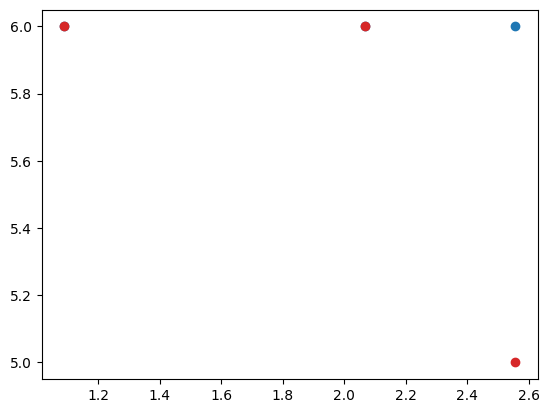

In [58]:
sen_nc_fci = df[(df["reference"] == "fci") * (df["cost"] == "NC") * (df["parity"] == "parity_4_sens.txt")]
# print(len(sen_nc_fci))

sen_nc_hf = df[(df["reference"] == "hf") * (df["cost"] == "NC") * (df["parity"] == "parity_4_sens.txt")]


plt.scatter(sen_nc_fci["bond_distance"], sen_nc_fci["K"], color="tab:blue")
plt.scatter(sen_nc_hf["bond_distance"], sen_nc_hf["K"], color="tab:red")

In [51]:
(df["reference"] == "fci") and (df["cost"] == "NC")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [18]:
metrics_data[0]["K"]

6